In [23]:
import pandas as pd
import numpy as np

train = pd.read_csv("../../data/optiver_volatility/train.csv")
print(train.shape)
print(train)

n_stocks = train["stock_id"].nunique()
n_time_ids = train["time_id"].nunique()
stocks_per_time = train.groupby("time_id")["stock_id"].nunique()
times_per_stock = train.groupby("stock_id")["time_id"].nunique()

print(f"train rows: {len(train):,}")
print(f"stocks: {n_stocks:,} | stock_id range: {train['stock_id'].min()} to {train['stock_id'].max()}")
print(f"time_ids: {n_time_ids:,} | time_id range: {train['time_id'].min()} to {train['time_id'].max()}")
print(f"missing stock-time rows from full grid: {n_stocks * n_time_ids - len(train):,}")

print("\nStocks per time_id:")
display(stocks_per_time.value_counts().sort_index().rename_axis("n_stocks").reset_index(name="n_time_ids"))

print("\nTime_ids per stock:")
display(times_per_stock.value_counts().sort_index().rename_axis("n_time_ids").reset_index(name="n_stocks"))

(428932, 3)
        stock_id  time_id    target
0              0        5  0.004136
1              0       11  0.001445
2              0       16  0.002168
3              0       31  0.002195
4              0       62  0.001747
...          ...      ...       ...
428927       126    32751  0.003461
428928       126    32753  0.003113
428929       126    32758  0.004070
428930       126    32763  0.003357
428931       126    32767  0.002090

[428932 rows x 3 columns]
train rows: 428,932
stocks: 112 | stock_id range: 0 to 126
time_ids: 3,830 | time_id range: 5 to 32767
missing stock-time rows from full grid: 28

Stocks per time_id:


,n_stocks,n_time_ids
0,111,28
1,112,3802



Time_ids per stock:


,n_time_ids,n_stocks
0,3815,1
1,3820,1
2,3829,3
3,3830,107


In [20]:
time_ids_sorted = np.array(sorted(train["time_id"].unique()))
split_idx = len(time_ids_sorted) // 2

train_time_ids = time_ids_sorted[:split_idx]
test_time_ids = time_ids_sorted[split_idx:]

train_split = train[train["time_id"].isin(train_time_ids)].copy()
test_split = train[train["time_id"].isin(test_time_ids)].copy()

print(f"train_split: {train_split.shape[0]:,} rows, {train_split['time_id'].nunique():,} time_ids")
print(f"test_split:  {test_split.shape[0]:,} rows, {test_split['time_id'].nunique():,} time_ids")
print(f"train time_id range: {train_time_ids.min()} to {train_time_ids.max()}")
print(f"test time_id range:  {test_time_ids.min()} to {test_time_ids.max()}")


train_split: 214,465 rows, 1,915 time_ids
test_split:  214,467 rows, 1,915 time_ids
train time_id range: 5 to 15852
test time_id range:  15853 to 32767


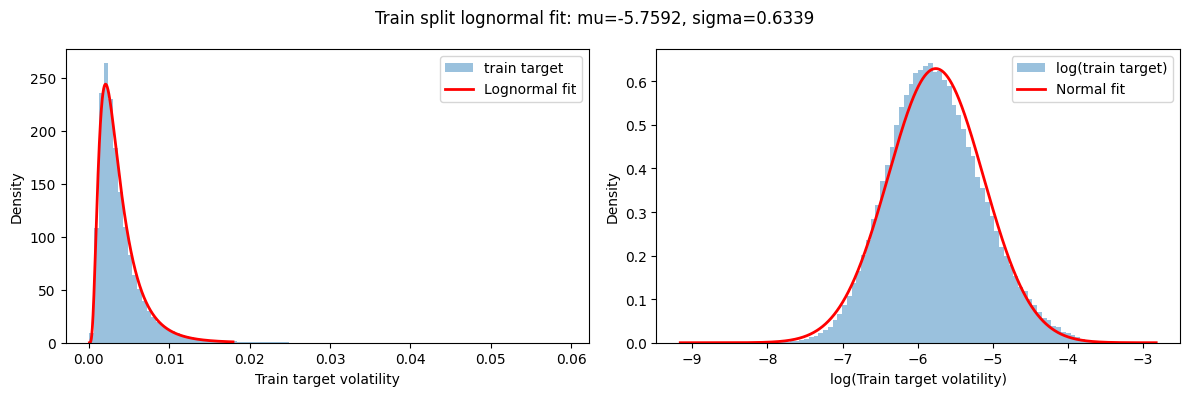

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

target = train_split["target"].dropna()
shape, loc, scale = lognorm.fit(target, floc=0)
mu = np.log(scale)
sigma = shape

x = np.linspace(target.min(), target.quantile(0.995), 1000)
log_target = np.log(target)
log_x = np.linspace(log_target.min(), log_target.max(), 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=100, density=True, alpha=0.45, label="train target")
axes[0].plot(x, lognorm.pdf(x, shape, loc=loc, scale=scale), color="red", linewidth=2, label="Lognormal fit")
axes[0].set_xlabel("Train target volatility")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(log_target, bins=100, density=True, alpha=0.45, label="log(train target)")
axes[1].plot(log_x, norm.pdf(log_x, mu, sigma), color="red", linewidth=2, label="Normal fit")
axes[1].set_xlabel("log(Train target volatility)")
axes[1].set_ylabel("Density")
axes[1].legend()


fig.suptitle(f"Train split lognormal fit: mu={mu:.4f}, sigma={sigma:.4f}")
plt.tight_layout()
plt.show()


In [27]:
stock_id = 0
time_id = train_time_ids[0]

book = pd.read_parquet(
    f"../../data/optiver_volatility/book_train.parquet/stock_id={stock_id}"
)

trade = pd.read_parquet(
    f"../../data/optiver_volatility/trade_train.parquet/stock_id={stock_id}"
)

target = train.loc[
    (train["stock_id"] == stock_id) &
    (train["time_id"] == time_id),
    "target"
].iloc[0]



print(f"stock_id = {stock_id}")
print(f"time_id  = {time_id}")
print(f"target   = {target}")



print("\nBOOK DATA")
print(book.shape)

display(book[book["time_id"] == time_id])

print("\nTRADE DATA")
display(trade[trade["time_id"] == time_id])



stock_id = 0
time_id  = 5
target   = 0.004135767

BOOK DATA
(917553, 10)


,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.001370,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.001370,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.001370,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.001370,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.001370,1.002405,3,126,2,100
...,...,...,...,...,...,...,...,...,...,...
297,5,585,1.003129,1.003749,1.003025,1.003801,100,3,26,3
298,5,586,1.003129,1.003749,1.002612,1.003801,100,3,2,3
299,5,587,1.003129,1.003749,1.003025,1.003801,100,3,26,3
300,5,588,1.003129,1.003749,1.002612,1.003801,100,3,2,3



TRADE DATA


,time_id,seconds_in_bucket,price,size,order_count
0,5,21,1.002301,326,12
1,5,46,1.002778,128,4
2,5,50,1.002818,55,1
3,5,57,1.003155,121,5
4,5,68,1.003646,4,1
5,5,78,1.003762,134,5
6,5,122,1.004207,102,3
7,5,127,1.004577,1,1
8,5,144,1.004370,6,1
9,5,147,1.003964,233,4
